In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import sys
import torch
import torchvision
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, sampler, random_split, Dataset
import copy
import math
from PIL import Image
import cv2
import albumentations as A  # our data augmentation library

import matplotlib.pyplot as plt
%matplotlib inline

# Custom modüller
sys.path.insert(0, "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/src")
from cb_loss import ClassBalancedDetectionClsLoss, compute_class_counts_from_coco
from training_logger import TrainingLogger

/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# remove arnings (optional)
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict, deque
import datetime
import time
from tqdm import tqdm # progress bar
from torchvision.utils import draw_bounding_boxes

In [3]:
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


PyCOCOTools provides many utilities for dealing with datasets in the COCO format, and if you wanted, you could evaluate the model's performance on the dataset with some of the utilities provided with this library.

That is out of scope for this notebook, however.

In [4]:
# our dataset is in cocoformat, we will need pypcoco tools
!pip install pycocotools
from pycocotools.coco import COCO

In [5]:
# Now, we will define our transforms
from albumentations.pytorch import ToTensorV2

In [7]:
def get_transforms(train=False):
    if train:
        transform = A.Compose([
            A.Resize(320, 320),
            A.HorizontalFlip(p=0.3),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', clip=True))
    else:
        transform = A.Compose([
            A.Resize(320, 320),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', clip=True))
    return transform

In [9]:
class ThermalDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        super().__init__(root, transforms, transform, target_transform)
        self.split = split
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]
    
    def _load_image(self, id: int):
        path = self.coco.loadImgs(id)[0]['file_name']
        image = cv2.imread(os.path.join(self.root, self.split, "images", path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))
    
    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = copy.deepcopy(self._load_target(id))
        
        boxes = [t['bbox'] + [t['category_id']] for t in target]
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)
        
        image = transformed['image']
        boxes = transformed['bboxes']
        
        new_boxes = []
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])
        
        boxes = torch.tensor(new_boxes, dtype=torch.float32)
        
        targ = {}
        targ['boxes'] = boxes
        # +1 offset: 0=background (Faster R-CNN iç kullanım), 1=Person, 2=Car, 3=OtherVehicle
        targ['labels'] = torch.tensor([t['category_id'] + 1 for t in target], dtype=torch.int64)
        targ['image_id'] = torch.tensor([t['image_id'] for t in target])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64)
        return image.div(255), targ

    def __len__(self):
        return len(self.ids)

In [10]:
dataset_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/merged_thermal_coco_augmented"

In [11]:
#load classes
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=2.81s)
creating index...
index created!


{0: {'id': 0, 'name': 'Person', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'Car', 'supercategory': 'none'},
 2: {'id': 2, 'name': 'OtherVehicle', 'supercategory': 'none'}}

In [12]:
classes = ['__background__'] + [i[1]['name'] for i in categories.items()]
classes  # 0=background, 1=Person, 2=Car, 3=OtherVehicle

['__background__', 'Person', 'Car', 'OtherVehicle']

In [13]:
train_dataset = ThermalDetection(root=dataset_path, transforms=get_transforms(True))

loading annotations into memory...
Done (t=2.83s)
creating index...
index created!


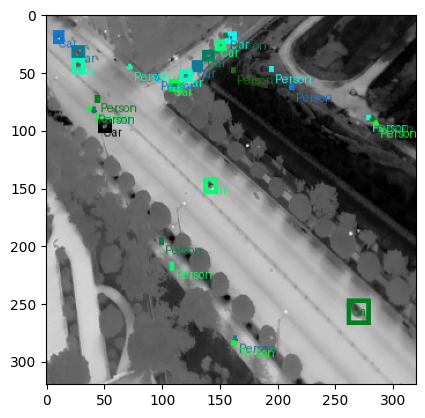

In [14]:
# Lets view a sample
sample = train_dataset[2]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [15]:
len(train_dataset)

62854

## Model

Our model is FasterRCNN with a backbone of `MobileNetV3-Large` (320px variant). This is the **lightest** Faster R-CNN in torchvision, optimized for edge/mobile devices.

Key advantages over ResNet50 backbone:
- ~10x fewer parameters (~19M vs ~41M)
- ~5x faster inference
- 320px min input size (vs 800px default)
- Designed for mobile/edge deployment

In [17]:
# En hafif Faster R-CNN: MobileNetV3-Large backbone, 320px input
model = models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes + 1)


This is our collating function for the train dataloader, it allows us to create batches of data that can be easily pass into the model

In [18]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)

The following blocks ensures that the model can take in the data and that it will not crash during training

In [20]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
model = model.to(device)

## Optimizer

Here, we define the optimizer. If you wish, you can also define the LR Scheduler, but it is not necessary for this notebook since our dataset is so small.

> Note, there are a few bugs with the current way `lr_scheduler` is implemented. If you wish to use the scheduler, you will have to fix those bugs

In [23]:
# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)

# Learning Rate Scheduler
num_epochs = 150
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Mixed Precision
scaler = torch.amp.GradScaler('cuda')

# Kayıt dizini
save_dir = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn"
os.makedirs(save_dir, exist_ok=True)

# Validation dataset
val_dataset = ThermalDetection(root=dataset_path, split="test", transforms=get_transforms(False))
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# Training Logger
logger = TrainingLogger(
    output_path=os.path.join(save_dir, "fasterrcnn_mobilenet_training.xlsx"),
    model_name="FasterRCNN-MobileNetV3-Large-320",
)
print(f"Weights -> {save_dir}")
print(f"Logger  -> {logger.output_path}")

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Train: 62854 | Val: 2387
Weights -> /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn
Logger  -> /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx


In [24]:
import torchvision.models.detection.roi_heads as roi_heads

# COCO annotation'dan otomatik sınıf sayıları
class_names_cb, class_counts_cb = compute_class_counts_from_coco(
    os.path.join(dataset_path, "train", "_annotations.coco.json")
)
print("Sınıf sayıları (CB Loss):")
for name, count in zip(class_names_cb, class_counts_cb):
    print(f"  {name:15s}: {count}")

# Class-Balanced Focal Loss (background_idx=0 for Faster R-CNN)
cb_cls_loss_fn = ClassBalancedDetectionClsLoss(
    class_counts=class_counts_cb,
    beta=0.9999,
    gamma=2.0,
    loss_type="focal",
    background_idx=0,
    device=device,
)

# Faster R-CNN'in classification loss'unu CB Focal Loss ile değiştir
def weighted_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
    labels = torch.cat(labels, dim=0)
    regression_targets = torch.cat(regression_targets, dim=0)

    # CB Focal Loss
    classification_loss = cb_cls_loss_fn(class_logits, labels)

    sampled_pos_inds_subset = torch.where(labels > 0)[0]
    labels_pos = labels[sampled_pos_inds_subset]
    N, num_classes = class_logits.shape
    box_regression = box_regression.reshape(N, box_regression.size(-1) // 4, 4)

    box_loss = F.smooth_l1_loss(
        box_regression[sampled_pos_inds_subset, labels_pos],
        regression_targets[sampled_pos_inds_subset],
        beta=1 / 9,
        reduction="sum",
    )
    box_loss = box_loss / labels.numel()

    return classification_loss, box_loss

roi_heads.fastrcnn_loss = weighted_fastrcnn_loss
print("\nCB Focal Loss ile weighted fastrcnn_loss aktif!")

Sınıf sayıları (CB Loss):
  Person         : 335428
  Car            : 577119
  OtherVehicle   : 36186

CB Focal Loss ile weighted fastrcnn_loss aktif!


In [25]:
import sys

## Training

The following is a function that will train the model for one epoch. Torchvision Object Detections models have a loss function built in, and it will calculate the loss automatically if you pass in the `inputs` and `targets`

In [23]:
def train_one_epoch(model, optimizer, loader, device, epoch, scaler):
    model.to(device)
    model.train()
    
    # İlk epoch'ta warmup
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(loader) - 1)
        warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=warmup_factor, total_iters=warmup_iters)
    
    all_losses = []
    all_losses_dict = []
    
    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        targets = [{k: torch.tensor(v).to(device) for k, v in t.items()} for t in targets]
        
        # Mixed Precision forward pass
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
        
        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()
        
        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)
        
        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping training")
            print(loss_dict)
            sys.exit(1)
        
        optimizer.zero_grad()
        scaler.scale(losses).backward()
        # Gradient clipping - patlayan gradientleri önler
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()
        
        if warmup_scheduler is not None:
            warmup_scheduler.step()
    
    all_losses_dict = pd.DataFrame(all_losses_dict)
    avg_loss = np.mean(all_losses)
    
    # Ortalama loss bileşenleri
    avg_losses = {
        'loss_classifier': all_losses_dict['loss_classifier'].mean(),
        'loss_box_reg': all_losses_dict['loss_box_reg'].mean(),
        'loss_rpn_box_reg': all_losses_dict['loss_rpn_box_reg'].mean(),
        'loss_objectness': all_losses_dict['loss_objectness'].mean(),
    }
    
    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], avg_loss,
        avg_losses['loss_classifier'],
        avg_losses['loss_box_reg'],
        avg_losses['loss_rpn_box_reg'],
        avg_losses['loss_objectness']
    ))
    return avg_loss, avg_losses

In [24]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Val seti uzerinde loss + precision + recall + mAP hesaplar."""
    from torchvision.ops import box_iou

    # --- 1) Val loss (train mode) ---
    model.train()
    loss_list = []
    for images, targets in loader:
        images = list(img.to(device) for img in images)
        tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.amp.autocast('cuda'):
            ld = model(images, tgts)
        loss_list.append({k: v.item() for k, v in ld.items()})
    loss_df = pd.DataFrame(loss_list)

    # --- 2) Predictions (eval mode) ---
    model.eval()
    all_preds, all_gts = [], []
    for images, targets in loader:
        images = list(img.to(device) for img in images)
        with torch.amp.autocast('cuda'):
            preds = model(images)
        all_preds.extend([{k: v.cpu() for k, v in p.items()} for p in preds])
        all_gts.extend([{k: v.clone() for k, v in t.items()} for t in targets])

    # --- 3) Precision, Recall, Accuracy (IoU>=0.5, conf>0.5) ---
    tp, fp, fn, correct, total_det = 0, 0, 0, 0, 0
    for pred, gt in zip(all_preds, all_gts):
        keep = pred['scores'] > 0.5
        pb, pl = pred['boxes'][keep], pred['labels'][keep]
        gb, gl = gt['boxes'], gt['labels']
        total_det += len(pb)
        if len(pb) == 0:
            fn += len(gb); continue
        if len(gb) == 0:
            fp += len(pb); continue
        ious = box_iou(pb, gb)
        matched = set()
        for i in range(len(pb)):
            best_val, best_j = ious[i].max(0)
            j = best_j.item()
            if best_val >= 0.5 and j not in matched and pl[i] == gl[j]:
                tp += 1; correct += 1; matched.add(j)
            else:
                fp += 1
        fn += len(gb) - len(matched)

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    acc  = correct / total_det if total_det > 0 else 0.0

    # --- 4) mAP (per-class AP, 101-point interpolation) ---
    fg_classes = list(range(1, n_classes + 1))

    def ap_at_iou(iou_t):
        aps = []
        for c in fg_classes:
            scores, matches, n_gt = [], [], 0
            for pred, gt in zip(all_preds, all_gts):
                gm = gt['labels'] == c
                n_gt += gm.sum().item()
                pm = pred['labels'] == c
                ps, pbox, gbox = pred['scores'][pm], pred['boxes'][pm], gt['boxes'][gm]
                if len(pbox) == 0: continue
                if len(gbox) == 0:
                    scores.extend(ps.tolist())
                    matches.extend([False] * len(ps))
                    continue
                iou = box_iou(pbox, gbox)
                used = set()
                for idx in ps.argsort(descending=True):
                    scores.append(ps[idx].item())
                    bv, bj = iou[idx].max(0)
                    j = bj.item()
                    if bv >= iou_t and j not in used:
                        matches.append(True); used.add(j)
                    else:
                        matches.append(False)
            if n_gt == 0: continue
            if not scores: aps.append(0.0); continue
            order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
            ms = [matches[i] for i in order]
            tp_c = np.cumsum(ms).astype(float)
            fp_c = np.cumsum([not m for m in ms]).astype(float)
            r = tp_c / n_gt
            p = tp_c / (tp_c + fp_c)
            ap = sum(p[r >= t].max() if (r >= t).any() else 0.0 for t in np.linspace(0, 1, 101)) / 101
            aps.append(ap)
        return np.mean(aps) if aps else 0.0

    m50 = ap_at_iou(0.5)
    m50_95 = np.mean([ap_at_iou(t) for t in np.arange(0.5, 1.0, 0.05)])

    return {
        'cls_loss': loss_df['loss_classifier'].mean(),
        'box_loss': loss_df['loss_box_reg'].mean() + loss_df['loss_rpn_box_reg'].mean(),
        'precision': prec,
        'recall': rec,
        'map50': m50,
        'map50_95': m50_95,
        'accuracy': acc,
    }

In [ ]:
# Checkpoint'tan devam etme + Eğitim
resume_path = os.path.join(save_dir, 'last.pt')
start_epoch = 0
best_loss = float('inf')

if os.path.exists(resume_path):
    print(f"Checkpoint bulundu: {resume_path}")
    checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint.get('loss', float('inf'))
    print(f"Epoch {checkpoint['epoch']}'dan devam ediliyor (loss: {checkpoint['loss']:.6f})")
else:
    print("Sıfırdan başlanıyor.")

for epoch in range(start_epoch, num_epochs):
    # --- Train ---
    avg_loss, avg_losses = train_one_epoch(model, optimizer, train_loader, device, epoch, scaler)
    lr_scheduler.step()

    # --- Eval (her epoch, tam val seti) ---
    print(f"  Eval ({len(val_dataset)} images)...")
    val = evaluate(model, val_loader, device)
    print(f"  Val -> cls:{val['cls_loss']:.4f} box:{val['box_loss']:.4f} "
          f"P:{val['precision']:.4f} R:{val['recall']:.4f} "
          f"mAP50:{val['map50']:.4f} mAP50-95:{val['map50_95']:.4f}")

    # --- Excel'e kaydet ---
    current_lr = optimizer.param_groups[0]['lr']
    logger.log_epoch(
        epoch=epoch,
        lr=current_lr,
        box_loss_train=avg_losses['loss_box_reg'] + avg_losses['loss_rpn_box_reg'],
        box_loss_val=val['box_loss'],
        cls_loss_train=avg_losses['loss_classifier'],
        cls_loss_val=val['cls_loss'],
        precision_val=val['precision'],
        recall_val=val['recall'],
        map50=val['map50'],
        map50_95=val['map50_95'],
        accuracy_val=val['accuracy'],
    )
    logger.save()

    # --- Checkpoint kaydet ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': lr_scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'loss': avg_loss,
    }, os.path.join(save_dir, 'last.pt'))

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, os.path.join(save_dir, 'best.pt'))
        print(f"  -> best.pt (loss: {avg_loss:.6f})")

    print(f"  -> Epoch {epoch}/{num_epochs} | LR: {current_lr:.6f}")

logger.save()
print(f"\nEğitim tamamlandı! En iyi loss: {best_loss:.6f}")
print(f"Metrikler: {logger.output_path}")

Sıfırdan başlanıyor.


100%|██████████| 1965/1965 [11:31<00:00,  2.84it/s]

Epoch 0, lr: 0.010000, loss: 0.295155, loss_classifier: 0.062738, loss_box: 0.089372, loss_rpn_box: 0.066968, loss_object: 0.076077
  Eval (2387 images)...


  Val -> cls:0.0152 box:0.1935 P:0.0391 R:0.1582 mAP50:0.0262 mAP50-95:0.0096
Metrikler kaydedildi: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx
  -> best.pt (loss: 0.295155)
  -> Epoch 0/150 | LR: 0.009999


100%|██████████| 1965/1965 [09:26<00:00,  3.47it/s]

...

  Val -> cls:0.0014 box:0.3694 P:0.2012 R:0.3581 mAP50:0.2525 mAP50-95:0.1518
Metrikler kaydedildi: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx
  -> Epoch 124/150 | LR: 0.000679


100%|██████████| 1965/1965 [07:46<00:00,  4.21it/s]

Epoch 125, lr: 0.000679, loss: 0.334354, loss_classifier: 0.000661, loss_box: 0.296441, loss_rpn_box: 0.020042, loss_object: 0.017209
  Eval (2387 images)...


  Val -> cls:0.0014 box:0.3667 P:0.2022 R:0.3579 mAP50:0.2486 mAP50-95:0.1518
Metrikler kaydedildi: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx
  -> Epoch 125/150 | LR: 0.000628


 31%|███       | 607/1965 [02:33<05:39,  4.00it/s]

In [ ]:
# our learning rate was too low, due to a lr scheduler bug. For this task, we wont need a scheudul.er

## Trying on sample Images

This is the inference code for the model. First, we set the model to evaluation mode and clear the GPU Cache. We also load a test dataset, so that we can use fresh images that the model hasn't seen.

In [26]:
# we will watch first epoich to ensure no errrors
# while it is training, lets write code to see the models predictions. lets try again
model.eval()
torch.cuda.empty_cache()

In [27]:
test_dataset = ThermalDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!


In [28]:
img, _ = test_dataset[5]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

In [33]:
import sys
sys.path.append("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection")

from src.plot_fasterrcnn_results import generate_all

xlsx_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx"
out_dir = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn"

generate_all(xlsx_path, out_dir)


FASTER R-CNN MOBILENET TRAINING RESULTS

Last Epoch (123):
  Box Loss    Train/Val: 0.2971 / 0.3645
  Class Loss  Train/Val: 0.0007 / 0.0015
  DFL Loss    Train/Val: 0.0201 / 0.0174
  Precision (Val): 0.1974
  Recall    (Val): 0.3557
  F1 Score  (Val): 0.2539
  mAP@0.5        : 0.2451
  mAP@0.5:0.95   : 0.1472
  Accuracy  (Val): nan

Best Values:
  mAP@0.5        : 0.2486 (Epoch 119)
  mAP@0.5:0.95   : 0.1474 (Epoch 119)
  Precision      : 0.2000 (Epoch 120)
  Recall         : 0.3575 (Epoch 121)
  F1             : 0.2555 (Epoch 120)
  Val Box Loss   : 0.1935 (Epoch 0)

Saved:
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/results.png
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/lr_schedule.png
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/confusion_matrix.png


{'results': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/results.png'),
 'lr': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/lr_schedule.png'),
 'cm': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster-cnn/confusion_matrix.png')}

In [32]:
# ============================================================
# TEST: best.pt ile test setinde degerlendir, metrikleri xlsx'e yaz
# ============================================================
import openpyxl
from torchvision.ops import box_iou

xlsx_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx"
best_ckpt = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/best.pt"

# En iyi checkpoint'i yukle
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()
print(f"Yuklendi: best.pt (epoch {ckpt.get('epoch','?')}, loss {ckpt.get('loss', float('nan')):.4f})")

# Sinif isimleri (Faster R-CNN: 0=background, 1..n_fg=classes)
fg_names = [categories[i]['name'] for i in sorted(categories.keys())]  # ['Person','Car','OtherVehicle']
cm_names = fg_names + ['background']
n_fg = len(fg_names)
cm_size = n_fg + 1

IOU_T, CONF_T = 0.5, 0.5

# Test loader
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False,
                         num_workers=2, collate_fn=collate_fn)

# Confusion matrix: satir=gercek sinif, sutun=tahmin. Son indeks=background
cm = np.zeros((cm_size, cm_size), dtype=np.int64)

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Test"):
        imgs = [im.to(device) for im in images]
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
        for pred, gt in zip(preds, targets):
            scores = pred['scores'].cpu()
            mask = scores > CONF_T
            p_boxes = pred['boxes'].cpu()[mask]
            p_labels = pred['labels'].cpu()[mask]
            p_scores = scores[mask]
            g_boxes = gt['boxes']
            g_labels = gt['labels']

            matched_gt, matched_pred = set(), set()
            if len(p_boxes) > 0 and len(g_boxes) > 0:
                ious = box_iou(p_boxes, g_boxes)
                order = torch.argsort(p_scores, descending=True).tolist()
                for pi in order:
                    best_val, best_j = ious[pi].max(0)
                    j = best_j.item()
                    if best_val >= IOU_T and j not in matched_gt:
                        gi = int(g_labels[j].item()) - 1
                        pj = int(p_labels[pi].item()) - 1
                        if 0 <= gi < n_fg and 0 <= pj < n_fg:
                            cm[gi, pj] += 1
                            matched_gt.add(j); matched_pred.add(pi)

            # Kacirilan GT'ler: Actual=class, Predicted=background
            for j in range(len(g_boxes)):
                if j not in matched_gt:
                    gi = int(g_labels[j].item()) - 1
                    if 0 <= gi < n_fg:
                        cm[gi, n_fg] += 1
            # Spurious / yanlis sinif: Actual=background, Predicted=class
            for pi in range(len(p_boxes)):
                if pi not in matched_pred:
                    pj = int(p_labels[pi].item()) - 1
                    if 0 <= pj < n_fg:
                        cm[n_fg, pj] += 1

# --- Metrikler ---
tp = np.array([cm[i, i] for i in range(n_fg)], dtype=np.int64)
fp = cm[:, :n_fg].sum(axis=0) - tp   # satirlar (background dahil) toplami - diagonal
fn = cm[:n_fg, :].sum(axis=1) - tp   # sutunlar (background dahil) toplami - diagonal

prec = tp / np.maximum(tp + fp, 1)
rec  = tp / np.maximum(tp + fn, 1)
f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-12)

total_tp  = int(tp.sum())
total_gt  = int(cm[:n_fg, :].sum())
total_pr  = int(cm[:, :n_fg].sum())
accuracy  = total_tp / max(total_gt, 1)
macro_p   = float(prec.mean())
macro_r   = float(rec.mean())
macro_f1  = float(f1.mean())

print("\nConfusion Matrix (satir=gercek, sutun=tahmin):")
print(" " * 14 + " ".join(f"{n:>13}" for n in cm_names))
for i, name in enumerate(cm_names):
    print(f"{name:>13} " + " ".join(f"{v:>13d}" for v in cm[i]))

print(f"\nAccuracy       : {accuracy:.4f}")
print(f"Macro Precision: {macro_p:.4f}")
print(f"Macro Recall   : {macro_r:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
for i, name in enumerate(fg_names):
    print(f"  {name:15s} P:{prec[i]:.4f}  R:{rec[i]:.4f}  F1:{f1[i]:.4f}  (TP:{tp[i]} FP:{fp[i]} FN:{fn[i]})")

# ============================================================
# Mevcut xlsx'e yaz (Confusion Matrix sheet + Test Results sheet)
# ============================================================
wb = openpyxl.load_workbook(xlsx_path)

# -- Confusion Matrix sheet --
ws_cm = wb["Confusion Matrix"]
for row in range(7, ws_cm.max_row + 5):
    for col in range(1, cm_size + 10):
        ws_cm.cell(row=row, column=col).value = None

ws_cm["B2"] = "Confusion Matrix \u2014 FasterRCNN-MobileNetV3-Large-320 (Test)"

header_row = 7
ws_cm.cell(row=header_row, column=3, value="Predicted \u2192")
for j, name in enumerate(cm_names):
    ws_cm.cell(row=header_row, column=4 + j, value=name)
ws_cm.cell(row=header_row + 1, column=2, value="Actual \u2193")

for i, name in enumerate(cm_names):
    r = header_row + 1 + i
    ws_cm.cell(row=r, column=3, value=name)
    for j in range(cm_size):
        ws_cm.cell(row=r, column=4 + j, value=int(cm[i, j]))

# Normalized CM (satir toplamina gore)
norm_start = header_row + cm_size + 3
ws_cm.cell(row=norm_start, column=3, value="Normalized Confusion Matrix (row %)")
ws_cm.cell(row=norm_start + 1, column=3, value="Actual \u2193")
for j, name in enumerate(cm_names):
    ws_cm.cell(row=norm_start + 1, column=4 + j, value=name)
for i, name in enumerate(cm_names):
    r = norm_start + 2 + i
    ws_cm.cell(row=r, column=3, value=name)
    row_sum = int(cm[i].sum())
    for j in range(cm_size):
        val = float(cm[i, j]) / row_sum if row_sum > 0 else 0.0
        ws_cm.cell(row=r, column=4 + j, value=round(val, 4))

# -- Test Results sheet --
if "Test Results" in wb.sheetnames:
    del wb["Test Results"]
ws_tr = wb.create_sheet("Test Results")
ws_tr["A1"] = "Metric"
ws_tr["B1"] = "Value"

summary = [
    ("Model",            "FasterRCNN-MobileNetV3-Large-320"),
    ("Checkpoint",       f"best.pt (epoch {ckpt.get('epoch','?')})"),
    ("Test images",      len(test_dataset)),
    ("IoU threshold",    IOU_T),
    ("Conf threshold",   CONF_T),
    ("Accuracy",         round(accuracy, 4)),
    ("Macro Precision",  round(macro_p, 4)),
    ("Macro Recall",     round(macro_r, 4)),
    ("Macro F1",         round(macro_f1, 4)),
    ("Total TP",         total_tp),
    ("Total GT",         total_gt),
    ("Total Predictions",total_pr),
]
for i, (k, v) in enumerate(summary, start=2):
    ws_tr.cell(row=i, column=1, value=k)
    ws_tr.cell(row=i, column=2, value=v)

# Per-class tablo
start = len(summary) + 4
headers = ["Class", "Precision", "Recall", "F1", "TP", "FP", "FN"]
for c, h in enumerate(headers, start=1):
    ws_tr.cell(row=start, column=c, value=h)
for i, name in enumerate(fg_names):
    r = start + 1 + i
    ws_tr.cell(row=r, column=1, value=name)
    ws_tr.cell(row=r, column=2, value=round(float(prec[i]), 4))
    ws_tr.cell(row=r, column=3, value=round(float(rec[i]),  4))
    ws_tr.cell(row=r, column=4, value=round(float(f1[i]),   4))
    ws_tr.cell(row=r, column=5, value=int(tp[i]))
    ws_tr.cell(row=r, column=6, value=int(fp[i]))
    ws_tr.cell(row=r, column=7, value=int(fn[i]))

wb.save(xlsx_path)
print(f"\nTest sonuclari xlsx'e kaydedildi: {xlsx_path}")


Yuklendi: best.pt (epoch 1, loss 0.2635)


Test: 100%|██████████| 299/299 [00:27<00:00, 10.90it/s]


Confusion Matrix (satir=gercek, sutun=tahmin):
                     Person           Car  OtherVehicle    background
       Person          2289             0             0         13963
          Car            13          5243            14         20820
 OtherVehicle             3            16           620           828
   background         84496         62401          3657             0

Accuracy       : 0.1861
Macro Precision: 0.0828
Macro Recall   : 0.2548
Macro F1       : 0.1239
  Person          P:0.0264  R:0.1408  F1:0.0444  (TP:2289 FP:84512 FN:13963)
  Car             P:0.0775  R:0.2010  F1:0.1119  (TP:5243 FP:62417 FN:20847)
  OtherVehicle    P:0.1445  R:0.4226  F1:0.2154  (TP:620 FP:3671 FN:847)

Test sonuclari xlsx'e kaydedildi: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn/fasterrcnn_mobilenet_training.xlsx
